# Emulation of Waves
## Weather Typing + Probabilistic - Copula Model
## Predictor- Load Weather Types

In [1]:
from bluemath_tk.core.io import load_model

daily_xwt = load_model("outputs/dwt_model_oporto.pkl")
dwts_to_fit = (
    daily_xwt.steps.get("pca")
    .pcs.kma_bmus.to_dataset(name="bmus")
    .sel(time=slice("1979", "2018"))
)
dwts_to_fit["cenEOFs"] = (
    ("n_clusters", "n_features"),
    daily_xwt.steps.get("kma").kma.cluster_centers_,
)
dwts_to_fit

<xarray.Dataset> Size: 193kB
Dimensions:  (time: 14610, n_clusters: 36, n_features: 123)
Coordinates:
  * time     (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Dimensions without coordinates: n_clusters, n_features
Data variables:
    bmus     (time) int32 58kB 23 23 23 23 23 23 28 28 ... 25 35 25 19 19 19 19
    cenEOFs  (n_clusters, n_features) float32 18kB -0.7486 -11.46 ... 0.03139

## Predictand- Load regional/local wave data
### significant wave height, peak period, mean wave direction

In [2]:
import xarray as xr

predictand = (
    xr.open_dataset("inputs/daily_predictand_1979_2018_Oporto.nc")
    .sel(time=dwts_to_fit.time, method="nearest", tolerance="1H")
    .rename({"swh": "bulk_Hs", "pp1d": "bulk_Tp", "mwd": "bulk_Dir"})
)
predictand["EF"] = predictand.bulk_Hs**2 + predictand.bulk_Tp
predictand["bmus"] = (("time"), dwts_to_fit["bmus"].values)
predictand

<xarray.Dataset> Size: 526kB
Dimensions:   (time: 14610)
Coordinates:
  * time      (time) datetime64[ns] 117kB 1979-01-01 1979-01-02 ... 2018-12-31
Data variables:
    bulk_Hs   (time) float32 58kB 2.554 2.351 3.297 3.99 ... 3.355 3.916 2.666
    bulk_Tp   (time) float32 58kB ...
    bulk_Dir  (time) float32 58kB ...
    ss        (time) float64 117kB ...
    EF        (time) float32 58kB 19.66 18.28 20.67 27.2 ... 19.72 25.42 15.28
    bmus      (time) int32 58kB 23 23 23 23 23 23 28 28 ... 25 35 25 19 19 19 19
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-05-05T16:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Predictand to Predictor- Model
## Probabilistic - Copula Model

In [3]:
from bluemath_tk.teslakit.climate_emulator import Climate_Emulator

ce = Climate_Emulator("outputs/emulator")

config = {
    "waves_families": ["bulk"],
    "distribution": [("ss", "Empirical")],
    "do_chromosomes": False,
    "extra_variables": ["ss"],
}
ce.FitExtremes(KMA=dwts_to_fit, WVS=predictand, config=config, proxy="EF")

Waves Families: ['bulk']
Extra Variables: ['ss']
GEV distribution: ['bulk_Hs', 'bulk_Tp']
Empirical distribution: ['bulk_Dir', 'ss']
Weibull distribution: []
Do chromosomes combinations: False
Max. Storms PROXY: EF


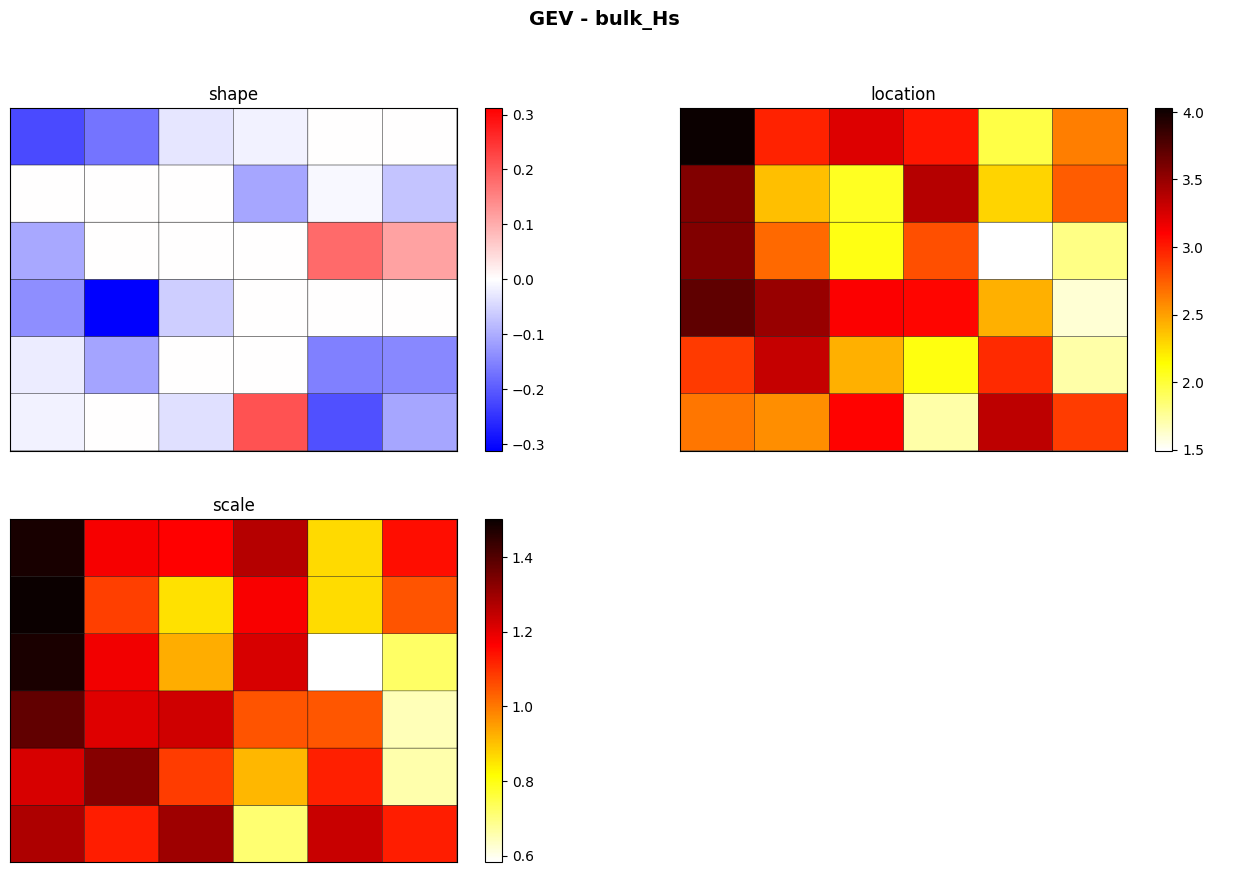

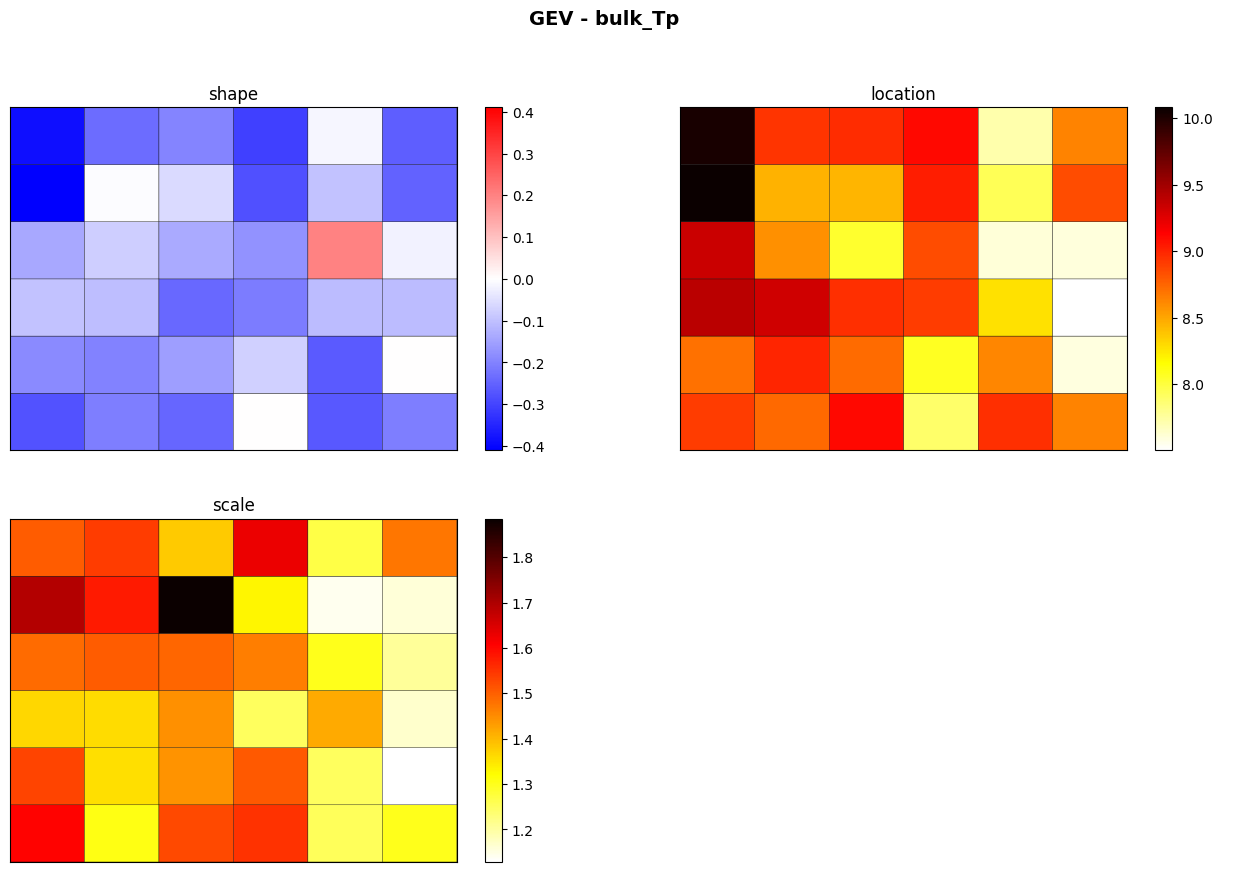

In [4]:
# Fit report figures

ce.Report_Fit(vns_GEV=["Hs", "Tp"], plot_chrom=False, plot_sigma=False);

## Climate Emulator
### Emulation of Weather Types + Emulation of Waves

In [5]:
# Load simulated DWTs

simulated_dwts = xr.open_dataset("outputs/xds_output.nc")
simulated_dwts

<xarray.Dataset> Size: 2MB
Dimensions:      (time: 36891, n_sim: 5)
Coordinates:
  * time         (time) datetime64[ns] 295kB 1999-01-01 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    evbmus_sims  (time, n_sim) int64 1MB ...
    ofbmus_sims  (time, n_sim) bool 184kB ...

In [6]:
simulated_waves = ce.Simulate_Waves(simulated_dwts.isel(n_sim=0), 1)
simulated_waves

C.E: Sim. Waves: 100%|██████████| 11269/11269 [02:06<00:00, 89.30it/s] 


<xarray.Dataset> Size: 1MB
Dimensions:   (n_sim: 3, time: 11269)
Coordinates:
  * time      (time) datetime64[ns] 90kB 1999-01-01 1999-01-04 ... 2100-01-01
Dimensions without coordinates: n_sim
Data variables:
    DWT       (n_sim, time) int64 270kB 23 32 23 19 9 19 3 ... 18 1 10 21 18 18
    bulk_Hs   (n_sim, time) float64 270kB 3.493 4.001 2.569 ... 5.301 3.468
    bulk_Tp   (n_sim, time) float64 270kB 10.84 9.735 7.989 ... 11.41 8.917
    bulk_Dir  (n_sim, time) float64 270kB 221.7 256.4 116.4 ... 83.6 223.6 201.7
    ss        (n_sim, time) float64 270kB 0.03116 0.06558 ... 0.04098 0.0373

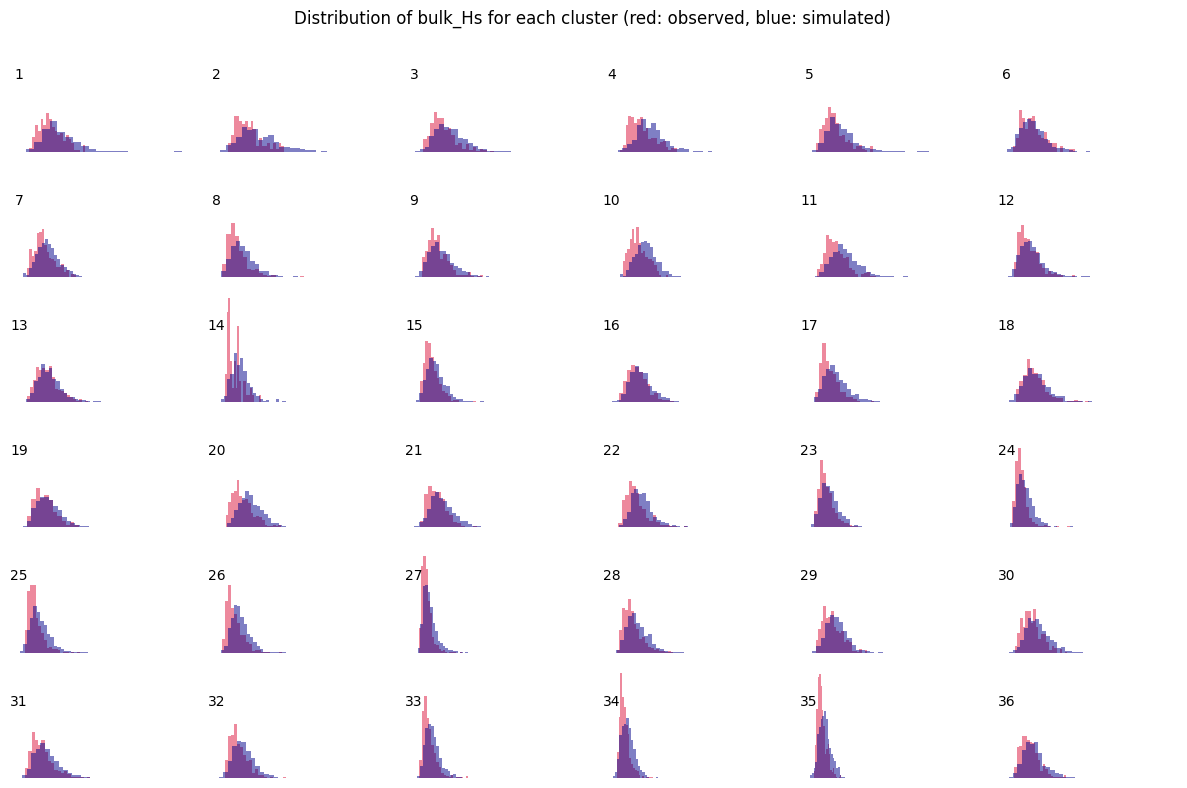

In [9]:
import matplotlib.pyplot as plt

var_to_plot = "bulk_Hs"

fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(time=predictand.groupby("bmus").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="crimson")
    simulated_waves.isel(time=simulated_waves.sel(n_sim=0).groupby("DWT").groups.get(cluster + 1))[
        var_to_plot
    ].plot.hist(ax=ax, density=True, alpha=0.5, bins=20, color="darkblue")
    ax.axis("off")
    ax.text(0, 0.7, f"{cluster + 1}", fontsize=10, ha="center", va="center")
    fig.suptitle(
        f"Distribution of {var_to_plot} for each cluster (red: observed, blue: simulated)",
        fontsize=12,
        ha="center",
        va="top",
    )
plt.subplots_adjust(top=0.9)
plt.tight_layout()

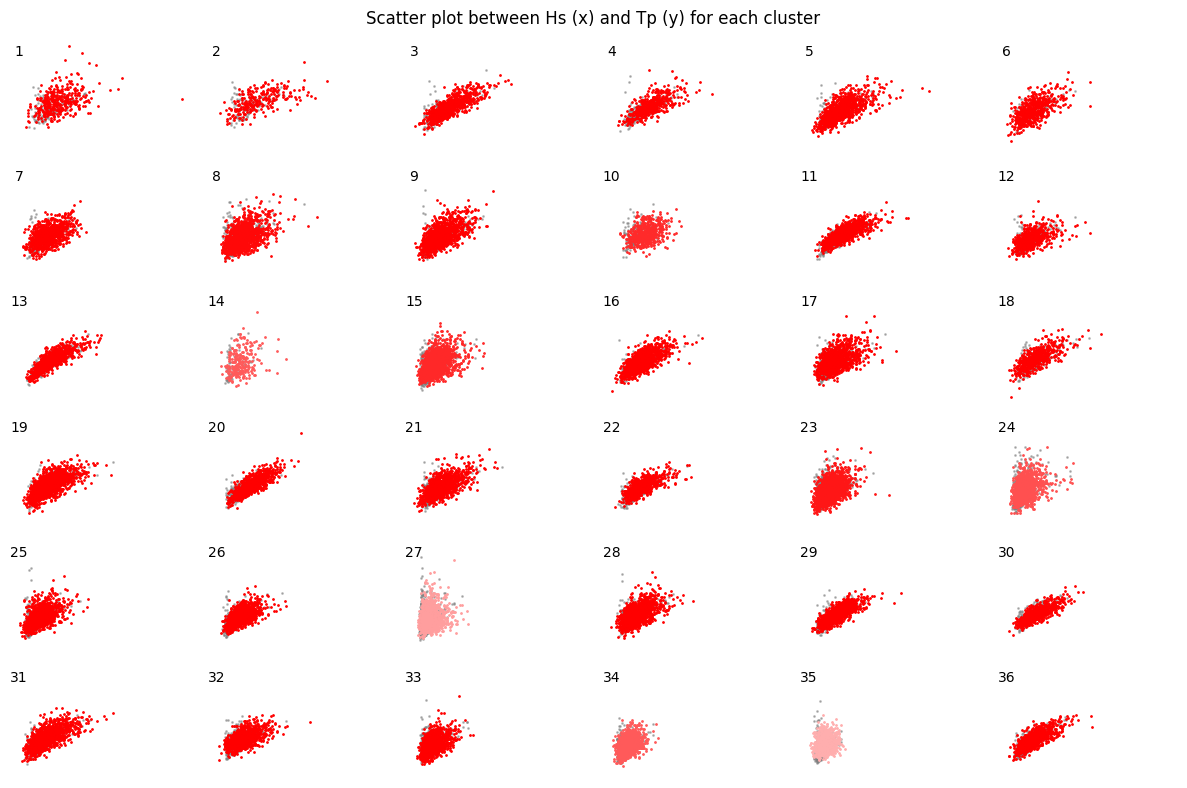

In [11]:
import matplotlib.colors as mcolors
import numpy as np

cmap = plt.cm.get_cmap("bwr")
norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
# Get correlation values
corr_values = np.array([ce.sigma[cluster][0]["corr"][0, 1] for cluster in range(1, 37)])
# Get colors for the correlation values
corr_values_colors = [cmap(norm(value)) for value in corr_values]
# Plot the correlation values
fig, axes = plt.subplots(6, 6, figsize=(12, 8), sharex=True, sharey=True)
for cluster, ax in enumerate(axes.flatten()):
    predictand.isel(
        time=predictand.groupby("bmus").groups.get(cluster + 1)
    ).plot.scatter(ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color="grey", alpha=0.5)
    simulated_waves.isel(
        time=simulated_waves.sel(n_sim=0).groupby("DWT").groups.get(cluster + 1)
    ).plot.scatter(
        ax=ax, x="bulk_Hs", y="bulk_Tp", s=1, color=corr_values_colors[cluster]
    )
    ax.axis("off")
    ax.text(0, 20, f"{cluster + 1}", fontsize=10, ha="center", va="center")
fig.suptitle(
    "Scatter plot between Hs (x) and Tp (y) for each cluster",
    fontsize=12,
    ha="center",
    va="top",
)
plt.subplots_adjust(top=0.9)
plt.tight_layout()

In [22]:
def t_rp(time_y):
    ny = len(time_y)
    return np.array([1/(1-(n/(ny+1))) for n in np.arange(1,ny+1)])
 
WVS_y=ce.WVS_MS.resample(time='1Y').max()
WVS_sim_y=simulated_waves.resample(time='1Y').max()
# WVS_y=CE.WVS_MS.resample(time='1Y').quantile(0.995)
# WVS_sim_y=WVS_sim.resample(time='1Y').quantile(0.995)
 
WVS_y_min=ce.WVS_MS.resample(time='1Y').min()
WVS_sim_y_min=simulated_waves.resample(time='1Y').min()
 
# RP calculation, var sorting historical
t_h = t_rp(WVS_y.time.dt.year)
t_s = t_rp(WVS_sim_y.time.dt.year)
 

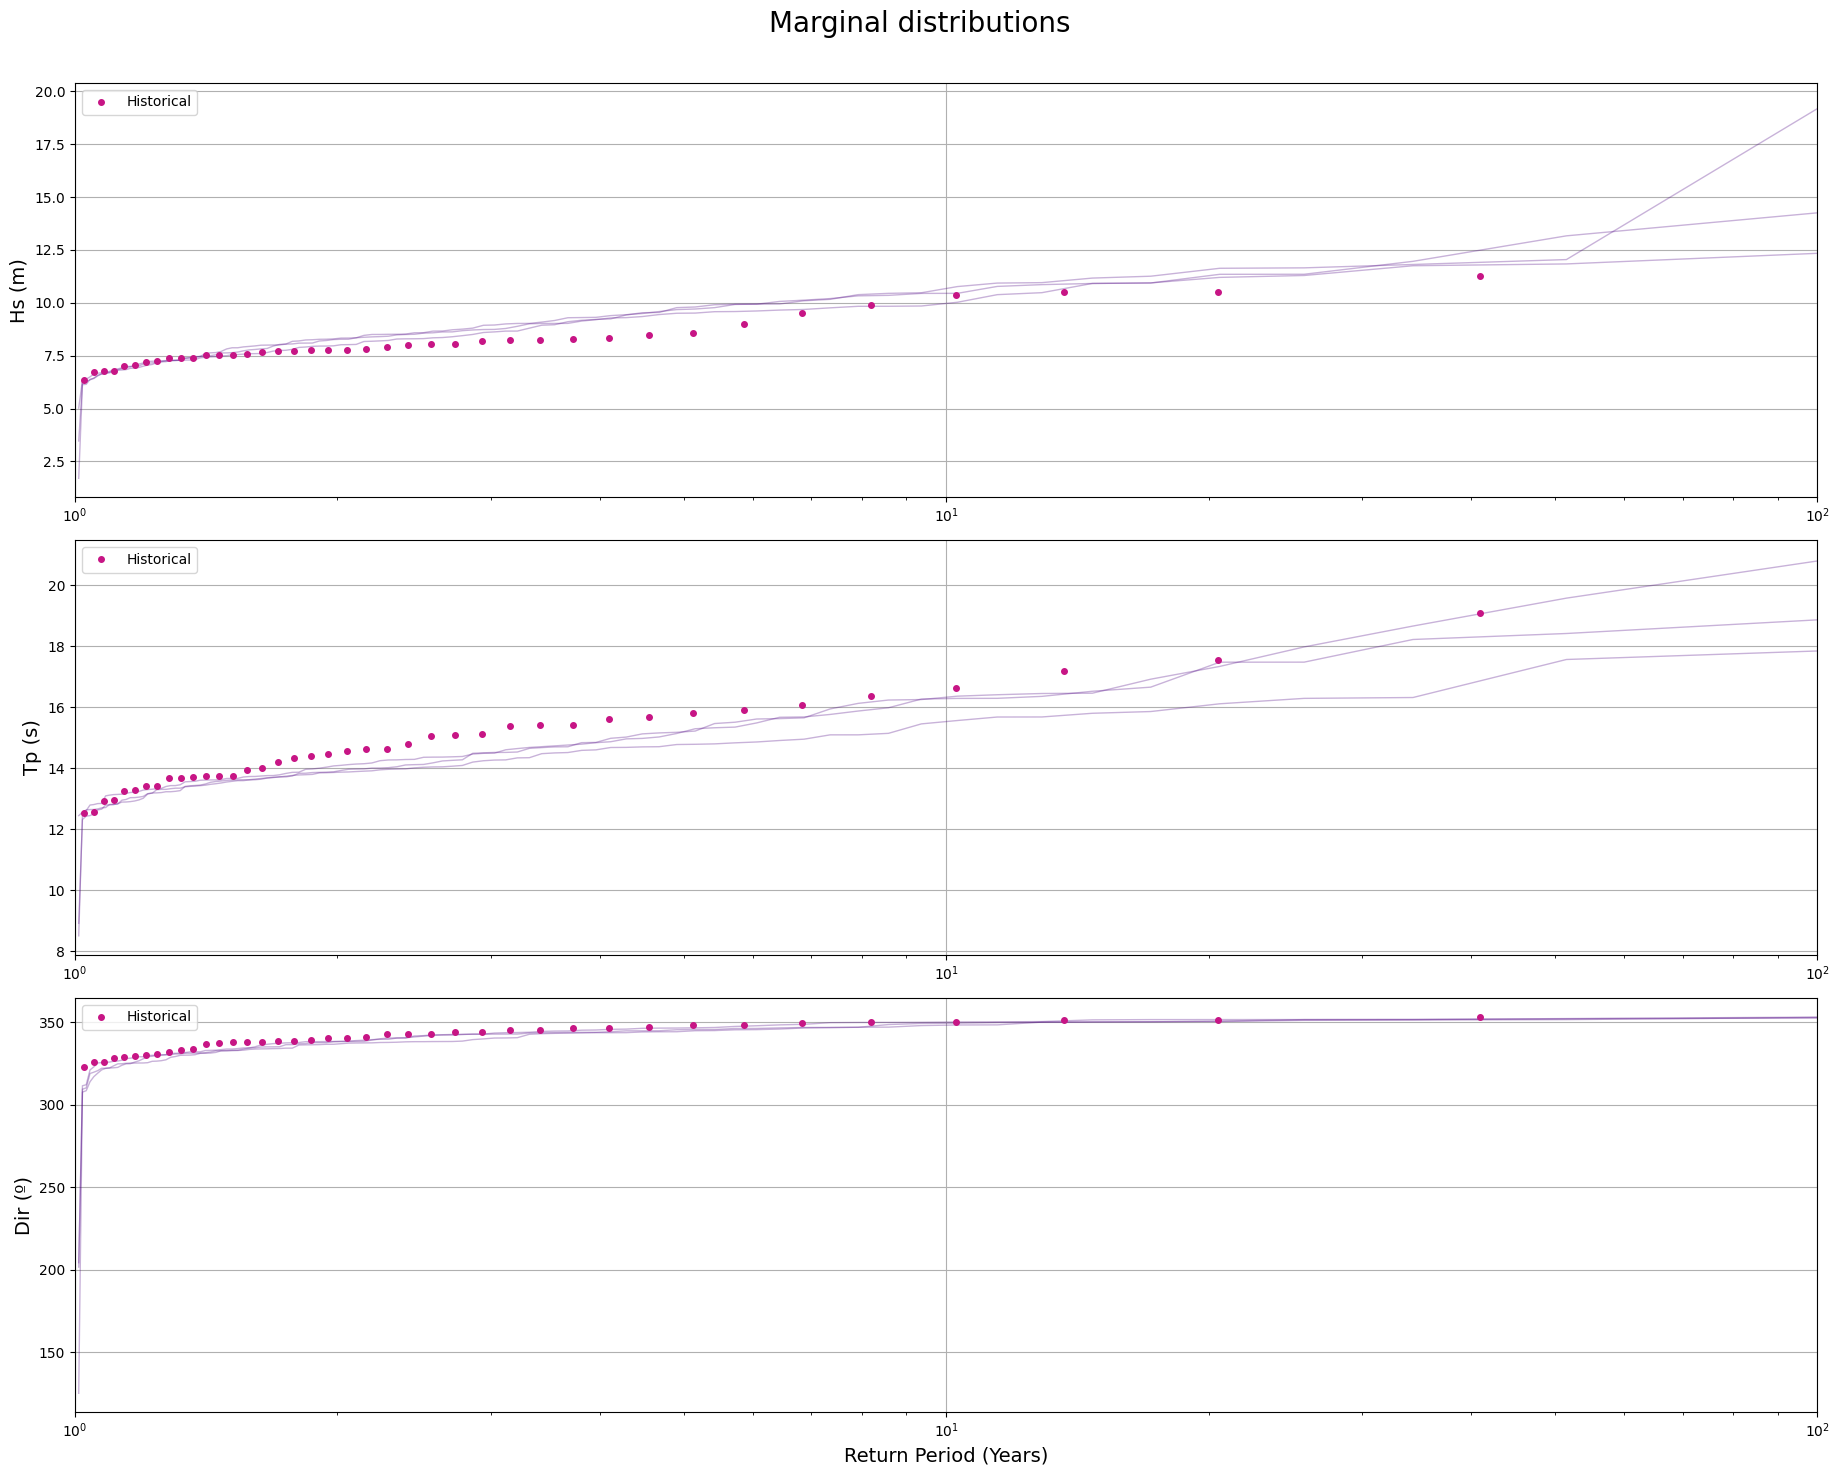

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

# Crear figura y ejes
fig = plt.figure(figsize=[18.5, 15])
gs1 = gridspec.GridSpec(3, 1)
ax = fig.add_subplot(gs1[0])
ax1 = fig.add_subplot(gs1[1])
ax2 = fig.add_subplot(gs1[2])

# ---- Hs ----
ax.semilogx(t_h, np.sort(WVS_y.bulk_Hs), 'o', color='mediumvioletred', 
            markersize=4, label='Historical', zorder=9)

# Plot individual simulations
for i in range(WVS_sim_y.dims['n_sim']):
    ax.semilogx(t_s, np.sort(WVS_sim_y.bulk_Hs.isel(n_sim=i)), 
                '-', color='indigo', alpha=0.3, linewidth=1)

ax.set_ylabel('Hs (m)', fontsize=14)
ax.set_xlim([1, 100])
ax.grid(True)
ax.legend()

# ---- Tp ----
ax1.semilogx(t_h, np.sort(WVS_y.bulk_Tp), 'o', color='mediumvioletred', 
             markersize=4, label='Historical', zorder=9)

for i in range(WVS_sim_y.dims['n_sim']):
    ax1.semilogx(t_s, np.sort(WVS_sim_y.bulk_Tp.isel(n_sim=i)), 
                 '-', color='indigo', alpha=0.3, linewidth=1)

ax1.set_ylabel('Tp (s)', fontsize=14)
ax1.set_xlim([1, 100])
ax1.grid(True)
ax1.legend()

# ---- Dir ----
ax2.semilogx(t_h, np.sort(WVS_y.bulk_Dir), 'o', color='mediumvioletred', 
             markersize=4, label='Historical', zorder=9)

for i in range(WVS_sim_y.dims['n_sim']):
    ax2.semilogx(t_s, np.sort(WVS_sim_y.bulk_Dir.isel(n_sim=i)), 
                 '-', color='indigo', alpha=0.3, linewidth=1)

# ax2.semilogx(t_s, np.sort(WVS_sim_y.bulk_Dir.mean('n_sim')), 
#              '-', color='black', linewidth=2, label='Simulation (mean)', zorder=8)

ax2.set_ylabel('Dir (º)', fontsize=14)
ax2.set_xlabel('Return Period (Years)', fontsize=14)
ax2.set_xlim([1, 100])
ax2.grid(True)
ax2.legend()

plt.suptitle('Marginal distributions', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
